In [ ]:
!uv pip install fastbook

In [23]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [2]:
import sys
print(sys.executable)
print(sys.version)

/home/ctristan/Documents/devlearning/Python Projects/FieldGuidePrototype/.venv/bin/python3
3.11.14 (main, Nov 19 2025, 22:47:14) [Clang 21.1.4 ]


In [16]:
import fastcore
import torch
from fastai.vision.all import *
from fastai.vision.widgets import *

In [20]:
import fastbook
fastbook.setup_book()

In [4]:
path = Path('training_data')
def label_func(path):
    return path.parent.name

In [5]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(size=256, min_scale=0.75)
)

dls = dblock.dataloaders(path, bs=64)

In [6]:
learn = vision_learner(dls, resnet50, metrics=accuracy)
learn.to_fp16()
learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,2.276572,2.403307,0.403423,11:45


epoch,train_loss,valid_loss,accuracy,time
0,1.261737,1.350636,0.643481,11:29
1,0.935407,0.987025,0.730206,07:18
2,0.688970,0.850977,0.768889,07:23
3,0.510582,0.718636,0.804003,07:16
4,0.422557,0.671544,0.816311,07:24


In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(5, nrows=10)

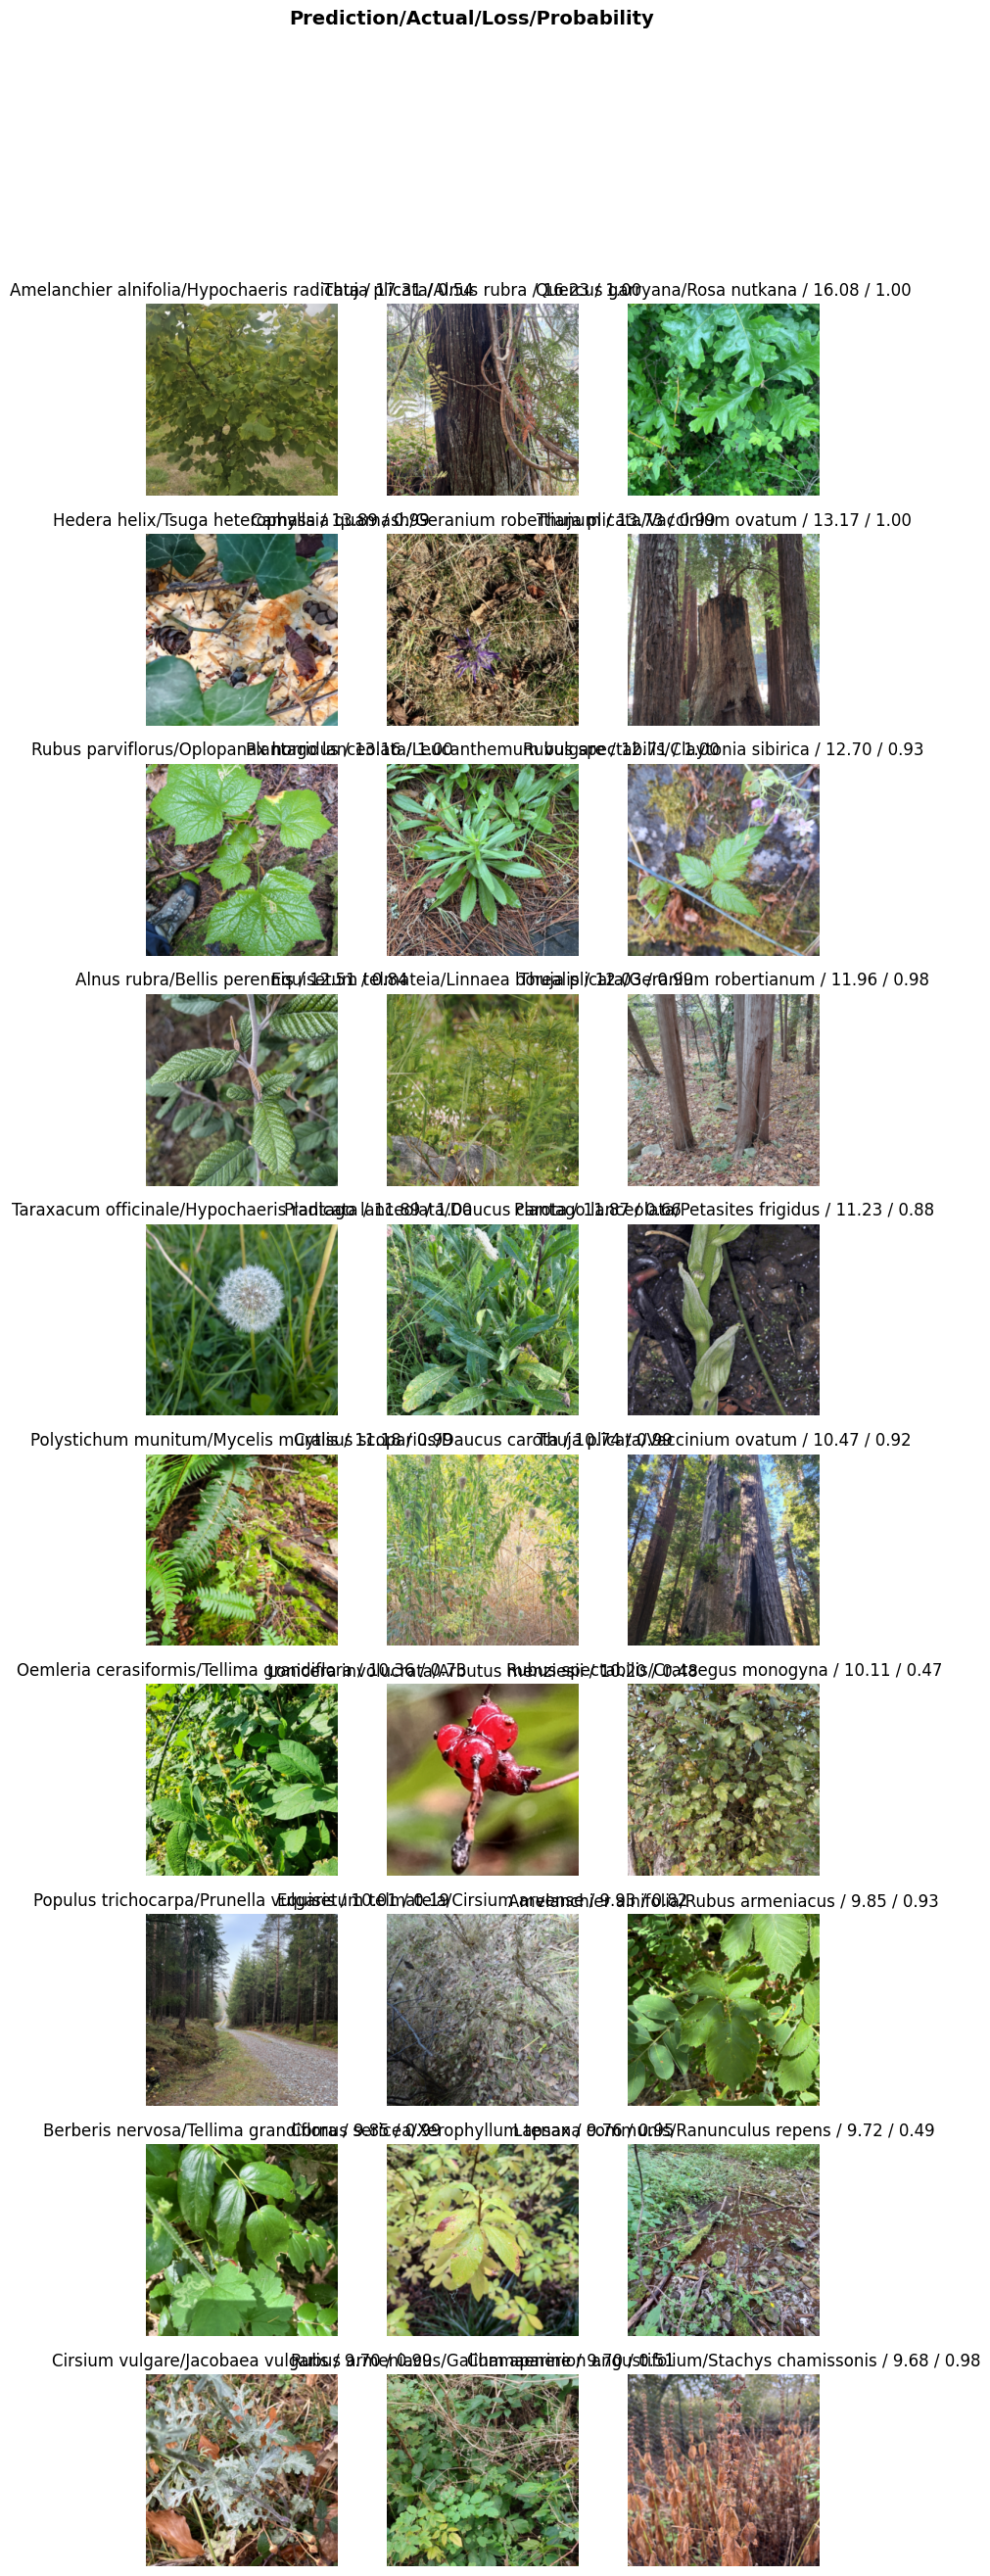

In [12]:
interp.plot_top_losses(30, nrows=10)

In [24]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [ ]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

In [ ]:
learn.save('plants_256_baseline')

In [ ]:
dblock_384 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(384),
    batch_tfms=aug_transforms(size=384, min_scale=0.75)
)

dls_384 = dblock_384.dataloaders(path, bs=32)

In [ ]:
learn = vision_learner(dls_384, resnet50, pretrained=False, metrics=[accuracy, error_rate])
learn.load('plants_256_baseline')

In [ ]:
learn.to_fp16()
learn.freeze()
learn.fit_one_cycle(2, 1e-3)

In [ ]:
learn.save('plants_384_baseline')

In [ ]:
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(20, nrows=5)

In [ ]:
learn = vision_learner(dls_384, resnet50, pretrained=False, metrics=[accuracy, error_rate])
learn.load('plants_384_baseline')

In [ ]:
learn.to_fp16()
learn.unfreeze()
learn.fit_one_cycle(10, lr_max=slice(1e-6, 1e-4))